# Compression Apporaches for Blendshapes

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from copy import deepcopy
import matplotlib.pyplot as plt
import numpy as np

from src.data import load_clip, extract_tracks, get_joint_idx

In [3]:
CLIP_IDX = 84

### Summary

- **Intense uniqueness problem**, should group blendshapes by unique values and times.
- No staticity problem (at least from tested clip), look like it is already handled by keyframing.
    - To Try: Completely delete the static tracks, ThreeJS should be able to handle it, should provide moderate size reduction.
- Moderate colinearity problem, some amount of colinear decimation should help reduce the size, but not as much. Force too much decimation may effect the animation too much.
- **Quantization is a must**, providing impressive compression and loss.
    - Heavy quantization on values is tangible, most values have narrow range -> low quantization loss.
    - To Consider: Hybrid compression rate: 8-bit for values, 16-bit for times, should provide almost no loss.
- Frame encoding as an alternative for times quantization (especially for known maximum number of keyframes/duration).
    - 120 Fps gives about the same quality as 16-bit quantization with same number of bits needed for clip with less than 9 minutes duration.

---
## Load Test Clip

In [4]:
original_clip = load_clip(f"data/json/clip_{CLIP_IDX}.json")

original_tracks = original_clip["animationClip"]["tracks"]
number_tracks = extract_tracks(original_tracks, type="number")
quater_tracks = extract_tracks(original_tracks, type="quaternion")

In [5]:
temp = deepcopy(original_clip)
temp["animationClip"]["tracks"] = "tracks"
temp

{'_id': {'$oid': '66e6b635f762103462fcb26c'},
 'animationClip': {'name': 'ไม่ดูแลช่องปาก-1726395951939',
  'duration': 7.328900000095354,
  'tracks': 'tracks',
  'uuid': '0c12c2b9-6709-49c8-a60b-49e23e5c3235',
  'blendMode': 2500},
 'recordDate': 1726395951972}

---
## Uniqueness

In [6]:
unique_data = []

for track in number_tracks:
    name = track["name"]
    times = track["times"]
    values = track["values"]

    if not unique_data:
        unique_data.append(dict(
            names=[name],
            times=times, 
            values=values,
        ))

    else:
        dup = False
        for data in unique_data:
            if len(times) == len(data["times"]):
                if np.allclose(times, data["times"]) & np.allclose(values, data["values"]):
                    data["names"].append(name)
                    dup = True
        
        if not dup:
            unique_data.append(dict(
                names=[name],
                times=times, 
                values=values,
            ))

In [7]:
print(f"num tracks: {len(number_tracks)}")
print(f"num unique tracks: {len(unique_data)}")

num tracks: 624
num unique tracks: 52


In [8]:
for data in unique_data:
    print(f"{len(data["names"])} {data["names"]}")

12 ['Alex_body_1.morphTargetInfluences[19]', 'Alex_body_2.morphTargetInfluences[19]', 'Alex_eyebrows.morphTargetInfluences[19]', 'Alex_iris_left_1.morphTargetInfluences[19]', 'Alex_iris_left_2.morphTargetInfluences[19]', 'Alex_iris_right_1.morphTargetInfluences[19]', 'Alex_iris_right_2.morphTargetInfluences[19]', 'Alex_teeth_down_1.morphTargetInfluences[19]', 'Alex_teeth_down_2.morphTargetInfluences[19]', 'Alex_teeth_up_1.morphTargetInfluences[19]', 'Alex_teeth_up_2.morphTargetInfluences[19]', 'Alex_tongue.morphTargetInfluences[19]']
12 ['Alex_body_1.morphTargetInfluences[38]', 'Alex_body_2.morphTargetInfluences[38]', 'Alex_eyebrows.morphTargetInfluences[38]', 'Alex_iris_left_1.morphTargetInfluences[38]', 'Alex_iris_left_2.morphTargetInfluences[38]', 'Alex_iris_right_1.morphTargetInfluences[38]', 'Alex_iris_right_2.morphTargetInfluences[38]', 'Alex_teeth_down_1.morphTargetInfluences[38]', 'Alex_teeth_down_2.morphTargetInfluences[38]', 'Alex_teeth_up_1.morphTargetInfluences[38]', 'Alex_

In [9]:
inspect_track = original_tracks[get_joint_idx(original_clip, name="Alex_body_1.morphTargetInfluences[44]")]
print(inspect_track)

{'name': 'Alex_body_1.morphTargetInfluences[44]', 'times': [0, 0.5455999970436096, 0.5622000098228455, 0.5788000226020813, 0.5957000255584717, 0.6287999749183655, 0.6460999846458435, 0.6789000034332275, 0.696399986743927, 0.7286999821662903, 0.7461000084877014, 0.7954000234603882, 0.8122000098228455, 0.8287000060081482, 0.8454999923706055, 0.8787000179290771, 0.8952000141143799, 0.9118000268936157, 0.9617999792098999, 0.9783999919891357, 0.9954000115394592, 1.0118000507354736, 1.0618000030517578, 1.0786999464035034, 1.0951000452041626, 1.1119999885559082, 1.1615999937057495, 1.1785999536514282, 1.195099949836731, 1.2115999460220337, 1.2616000175476074, 1.2790000438690186, 1.3282999992370605, 1.3449000120162964, 1.3615000247955322, 1.3782000541687012, 1.3950999975204468, 1.4117000102996826, 1.4280999898910522, 1.4448000192642212, 1.4615000486373901, 1.4781999588012695, 1.4946999549865723, 1.5113999843597412, 1.528499960899353, 1.544700026512146, 1.5613000392913818, 1.5779999494552612, 1

---
## Staticity

In [10]:
for i, data in enumerate(unique_data):
    names = data["names"]
    times = data["times"]
    values = data["values"]
    
    length = len(values)
    max_val = np.max(values)
    min_val = np.min(values)

    print(f"group {i:<3} |  members = {len(names):<3} | len = {length:<5} |  minmax = ({min_val:.6f}, {max_val:.6f})  |  range = {max_val - min_val:.6f}")

group 0   |  members = 12  | len = 327   |  minmax = (0.055628, 0.289826)  |  range = 0.234198
group 1   |  members = 12  | len = 327   |  minmax = (0.041380, 0.333070)  |  range = 0.291691
group 2   |  members = 12  | len = 43    |  minmax = (0.000000, 0.129201)  |  range = 0.129201
group 3   |  members = 12  | len = 22    |  minmax = (0.000000, 0.052906)  |  range = 0.052906
group 4   |  members = 12  | len = 327   |  minmax = (0.037368, 0.214126)  |  range = 0.176758
group 5   |  members = 12  | len = 327   |  minmax = (0.019776, 0.055045)  |  range = 0.035269
group 6   |  members = 12  | len = 327   |  minmax = (0.019675, 0.052302)  |  range = 0.032626
group 7   |  members = 12  | len = 109   |  minmax = (0.000000, 0.308451)  |  range = 0.308451
group 8   |  members = 12  | len = 109   |  minmax = (0.000000, 0.308402)  |  range = 0.308402
group 9   |  members = 12  | len = 309   |  minmax = (0.000000, 0.355007)  |  range = 0.355007
group 10  |  members = 12  | len = 327   |  minmax

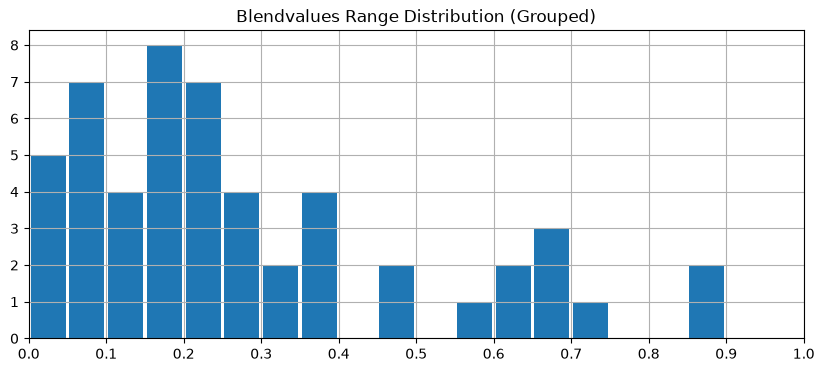

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(10,4))

ranges = [np.max(data["values"]) - np.min(data["values"]) for data in unique_data]
ax.hist(ranges, bins=np.linspace(0, 1, 21), rwidth=0.9)
ax.set_title("Blendvalues Range Distribution (Grouped)")
ax.set_xbound(0.0, 1.0)
ax.set_xticks(np.linspace(0, 1, 11))
ax.grid()
plt.show()

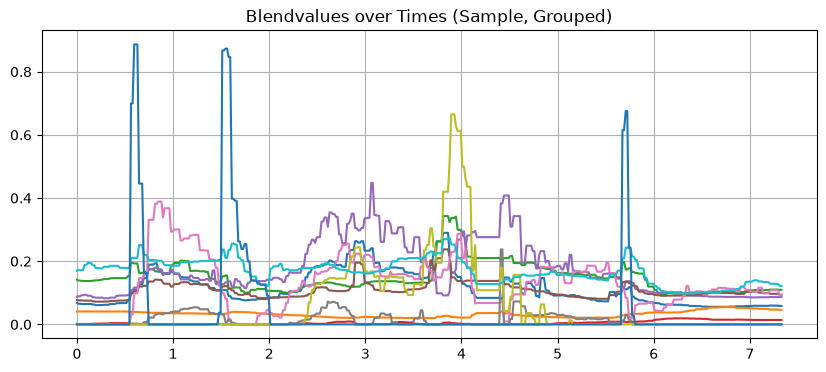

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(10,4))

for i, data in enumerate(unique_data[::5]):
    names = data["names"]
    times = data["times"]
    values = data["values"]
    ax.plot(times, values)

ax.set_title("Blendvalues over Times (Sample, Grouped)")
ax.grid()
plt.show()

---
## Colinearity

In [13]:
def colinear_decimation(times, values, threshold=1e-3):
    vecs = np.stack([times, values], axis=1)
    i = 1
    while i < vecs.shape[0] - 1:
            v = vecs[i + 1] - vecs[i - 1]
            w = vecs[i] - vecs[i - 1]
            projection_weight = np.dot(w, v) / np.linalg.norm(v) ** 2
            perpendicular_vec = w - projection_weight * v
            perpendicular_dist = np.linalg.norm(perpendicular_vec)

            if perpendicular_dist <= threshold:
                vecs = np.delete(vecs, i, axis=0)
            else:
                i += 1
            
    return vecs

original 327
decimated 303


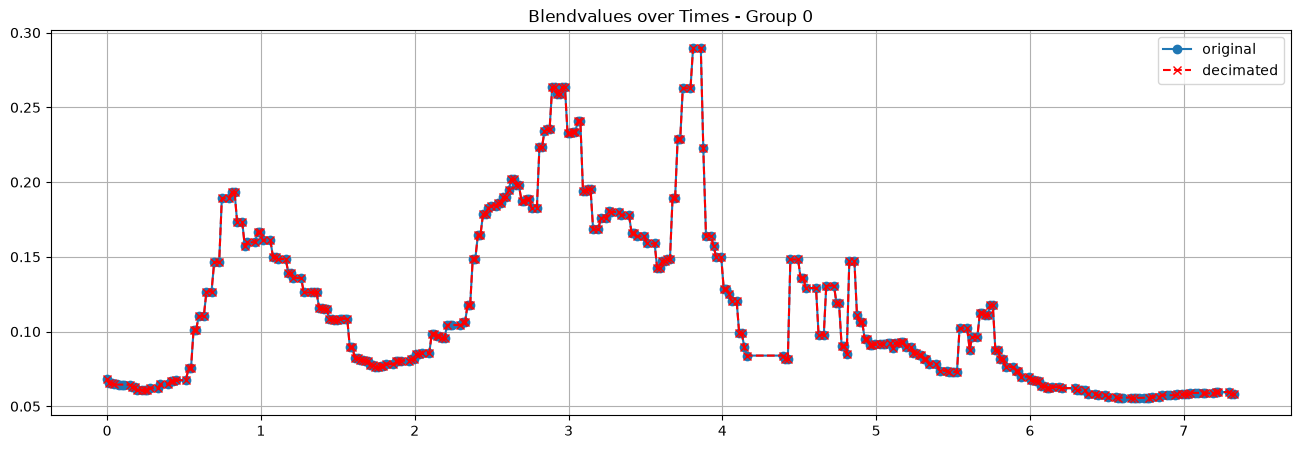

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(16,5))

group_idx = 0
test_cld = colinear_decimation(unique_data[group_idx]["times"], unique_data[group_idx]["values"], threshold=1e-4)

print("original", len(unique_data[group_idx]["values"]))
print("decimated", test_cld.shape[0])

ax.plot(unique_data[group_idx]["times"], unique_data[group_idx]["values"], 'o-', label="original")
ax.plot(test_cld[:, 0], test_cld[:, 1], 'rx--', label="decimated")

ax.set_title(f"Blendvalues over Times - Group {group_idx}")
ax.legend()
ax.grid()
plt.show()

---
## Quantization

In [15]:
def quantize(data, q_type=np.uint8):
    data_min, data_max = np.min(data), np.max(data)
    num_bits = np.dtype(q_type).itemsize * 8

    scale = (data_max - data_min) / (2 ** num_bits - 1)
    zero  = np.round(-data_min / scale)
    codes = np.round(data / scale) + zero

    return codes.astype(q_type), scale, zero

def dequantize(codes, scale, zero):
    return scale * (codes - zero)

In [16]:
codes, scale, zero = quantize(original_tracks[2]["values"])
codes

array([240, 217, 217, 215, 215, 214, 214, 215, 215, 249, 249, 255, 255,
       248, 248, 237, 237, 170, 170, 155, 155, 160, 160, 138, 138,   0,
         0,  16,  16,  23,  23,  45,  45,  30,  30,  88,  88, 103, 103,
        49,  49,   0,   0], dtype=uint8)

In [17]:
dequantize(codes, scale, zero)

array([0.12160105, 0.10994761, 0.10994761, 0.10893427, 0.10893427,
       0.1084276 , 0.1084276 , 0.10893427, 0.10893427, 0.12616109,
       0.12616109, 0.12920111, 0.12920111, 0.12565442, 0.12565442,
       0.12008104, 0.12008104, 0.08613408, 0.08613408, 0.07853401,
       0.07853401, 0.08106737, 0.08106737, 0.0699206 , 0.0699206 ,
       0.        , 0.        , 0.00810674, 0.00810674, 0.01165343,
       0.01165343, 0.0228002 , 0.0228002 , 0.01520013, 0.01520013,
       0.04458705, 0.04458705, 0.05218712, 0.05218712, 0.02482688,
       0.02482688, 0.        , 0.        ])

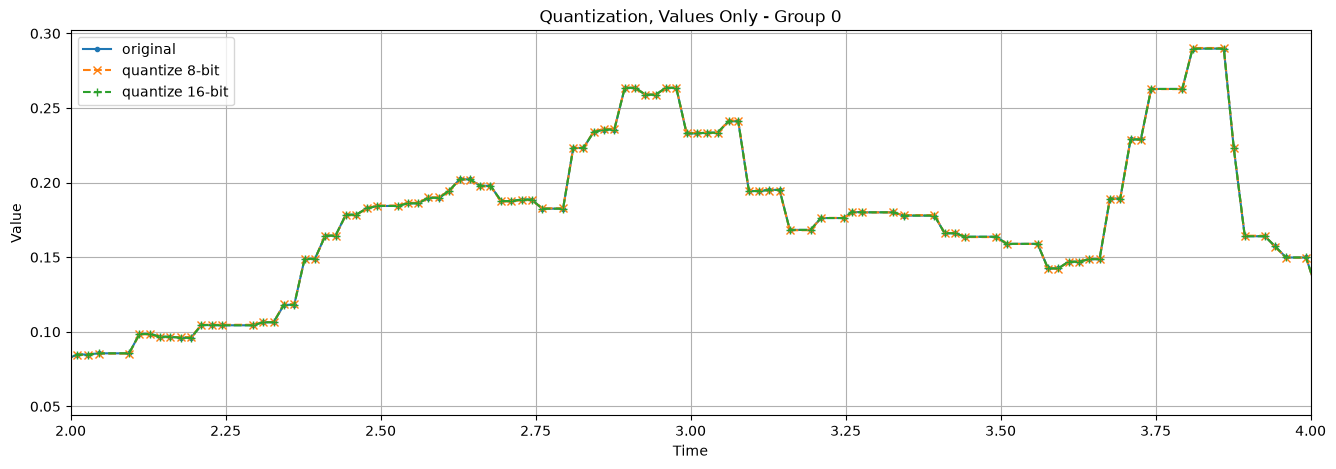

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(16,5))

group_idx = 0

codes8 , scale8 , zero8  = quantize(unique_data[group_idx]["values"], q_type=np.uint8)
codes16, scale16, zero16 = quantize(unique_data[group_idx]["values"], q_type=np.uint16)
dq_values8  = dequantize(codes8, scale8, zero8)
dq_values16 = dequantize(codes16, scale16, zero16)

ax.plot(unique_data[group_idx]["times"], unique_data[group_idx]["values"], '.-', label="original")
ax.plot(unique_data[group_idx]["times"], dq_values8 , 'x--', label="quantize 8-bit")
ax.plot(unique_data[group_idx]["times"], dq_values16, '+--', label="quantize 16-bit")

ax.set_title(f"Quantization, Values Only - Group {group_idx}")
ax.set_xlabel("Time")
ax.set_ylabel("Value")
ax.set_xbound(2, 4)
ax.legend()
ax.grid()
plt.show()

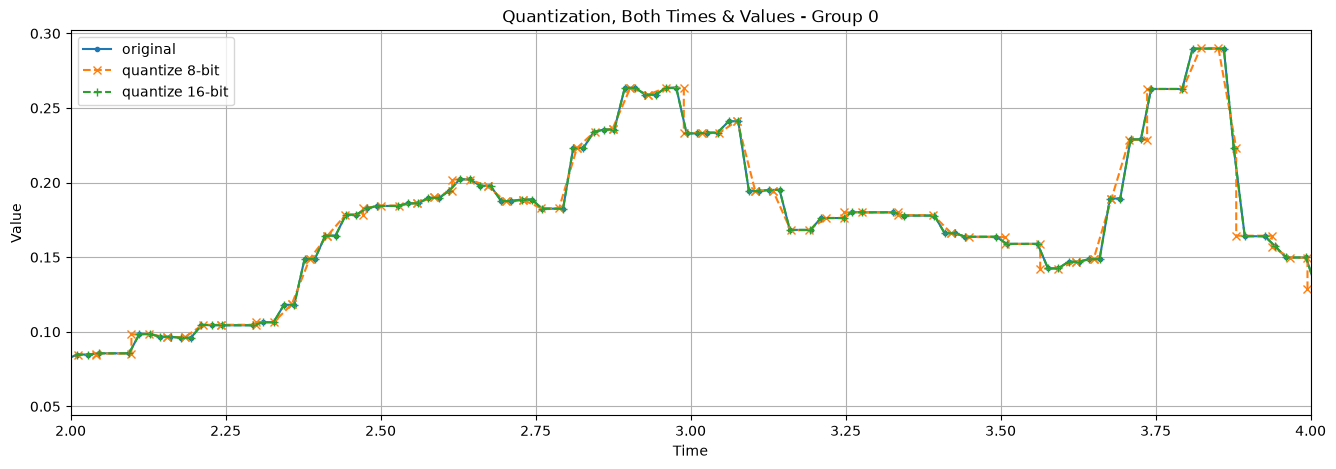

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(16,5))

group_idx = 0

v_codes8 , v_scale8 , v_zero8  = quantize(unique_data[group_idx]["values"], q_type=np.uint8)
v_codes16, v_scale16, v_zero16 = quantize(unique_data[group_idx]["values"], q_type=np.uint16)
t_codes8 , t_scale8 , t_zero8  = quantize(unique_data[group_idx]["times"], q_type=np.uint8)
t_codes16, t_scale16, t_zero16 = quantize(unique_data[group_idx]["times"], q_type=np.uint16)

dq_values8  = dequantize(v_codes8 , v_scale8 , v_zero8)
dq_values16 = dequantize(v_codes16, v_scale16, v_zero16)
dq_times8  = dequantize(t_codes8 , t_scale8 , t_zero8)
dq_times16 = dequantize(t_codes16, t_scale16, t_zero16)

ax.plot(unique_data[group_idx]["times"], unique_data[group_idx]["values"], '.-', label="original")
ax.plot(dq_times8 , dq_values8 , 'x--', label="quantize 8-bit")
ax.plot(dq_times16, dq_values16, '+--', label="quantize 16-bit")

ax.set_title(f"Quantization, Both Times & Values - Group {group_idx}")
ax.set_xlabel("Time")
ax.set_ylabel("Value")
ax.set_xbound(2, 4)
ax.legend()
ax.grid()
plt.show()

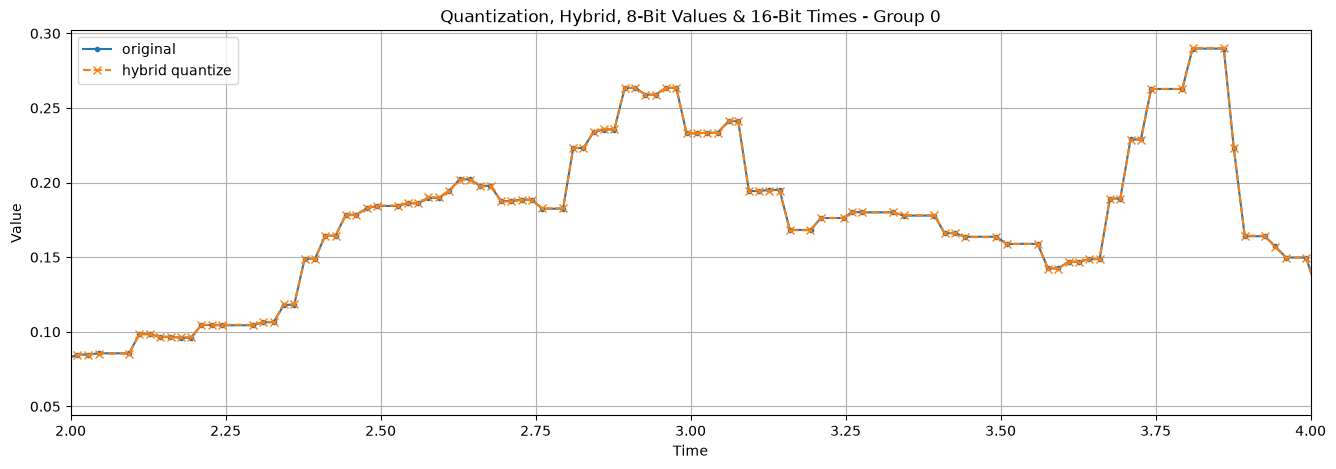

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(16,5))

group_idx = 0

v_codes, v_scale, v_zero = quantize(unique_data[group_idx]["values"], q_type=np.uint8)
t_codes, t_scale, t_zero = quantize(unique_data[group_idx]["times"] , q_type=np.uint16)

dq_values = dequantize(v_codes, v_scale, v_zero)
dq_times  = dequantize(t_codes, t_scale, t_zero)

ax.plot(unique_data[group_idx]["times"], unique_data[group_idx]["values"], '.-', label="original")
ax.plot(dq_times, dq_values , 'x--', label="hybrid quantize")

ax.set_title(f"Quantization, Hybrid, 8-Bit Values & 16-Bit Times - Group {group_idx}")
ax.set_xlabel("Time")
ax.set_ylabel("Value")
ax.set_xbound(2, 4)
ax.legend()
ax.grid()
plt.show()

---
## Framing

In [21]:
fps = 120
duration = original_clip["animationClip"]["duration"]
num_frames = np.ceil(fps * duration).astype(int)
print("num frame:", num_frames, ", require", np.ceil(np.log2(num_frames)).astype(int), "bits")

num frame: 880 , require 10 bits


In [22]:
2**16 / fps # maximum duration for 16-bit frame encoding

546.1333333333333

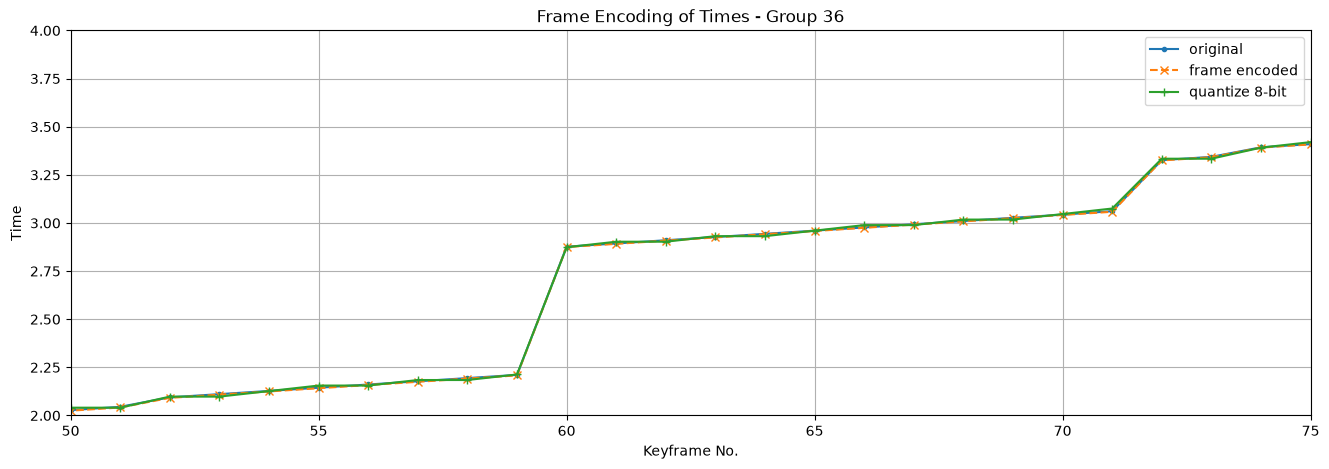

In [23]:
fig, ax = plt.subplots(1, 1, figsize=(16,5))

group_idx = 36

frame_idx = np.round(np.array(unique_data[group_idx]["times"]) * fps).astype(int)
decode_times = frame_idx / fps

t_codes, t_scale, t_zero = quantize(unique_data[group_idx]["times"] , q_type=np.uint8)
dq_times  = dequantize(t_codes, t_scale, t_zero)

ax.plot(unique_data[group_idx]["times"], '.-', label="original")
ax.plot(decode_times, 'x--', label="frame encoded")
ax.plot(dq_times, '+-', label="quantize 8-bit")

ax.set_title(f"Frame Encoding of Times - Group {group_idx}")
ax.set_xlabel("Keyframe No.")
ax.set_ylabel("Time")
ax.set_xbound(50, 75)
ax.set_ybound(2, 4)
ax.legend()
ax.grid()
plt.show()

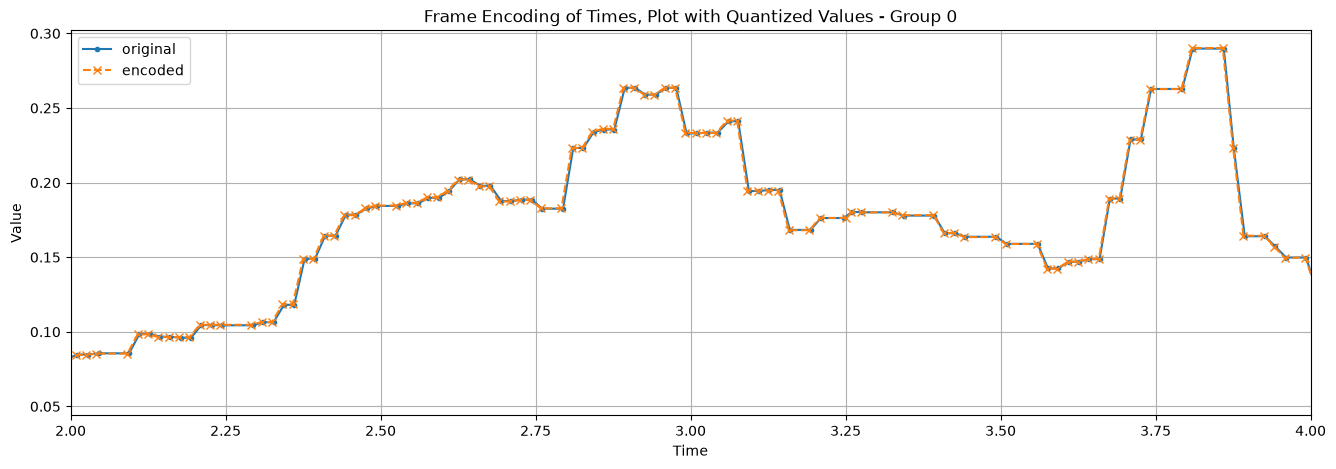

In [24]:
fig, ax = plt.subplots(1, 1, figsize=(16,5))

group_idx = 0

v_codes, v_scale, v_zero = quantize(unique_data[group_idx]["values"], q_type=np.uint8)
dq_values = dequantize(v_codes, v_scale, v_zero)

frame_idx = np.round(np.array(unique_data[group_idx]["times"]) * fps).astype(int)
decode_times = frame_idx / fps

dq_times  = dequantize(t_codes, t_scale, t_zero)

ax.plot(unique_data[group_idx]["times"], unique_data[group_idx]["values"], '.-', label="original")
ax.plot(decode_times, dq_values, 'x--', label="encoded")

ax.set_title(f"Frame Encoding of Times, Plot with Quantized Values - Group {group_idx}")
ax.set_xlabel("Time")
ax.set_ylabel("Value")
ax.set_xbound(2, 4)
ax.legend()
ax.grid()
plt.show()

---
## End-to-End Blendshapes Compression Test

In [39]:
%load_ext autoreload
%autoreload 2

import os
from src.compression.blendshapes import BlendShapesCompressor
from src.compression.clip import ClipCompressor
from src.compression.baseline import RawBase64Compressor, QuantizeCompressor
from src.data import save_clip, load_clip
from src.eval import memory_saving_matrix

idx = 73
original_path = f"data/json/clip_{idx}.json"
baseline_path = f"out/temp/clip_{idx}_rawb64_baseline.json"
blendshape_path = f"out/temp/clip_{idx}_blendshapes_compress_test.json"

original_clip = load_clip(original_path)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [40]:
compressor = ClipCompressor(blendshapes_compressor=BlendShapesCompressor())
compressed_clip = compressor.compress(original_clip)
save_clip(compressed_clip, blendshape_path)

In [41]:
rawb64_clip = RawBase64Compressor().compress(original_clip)
save_clip(rawb64_clip, baseline_path)

In [47]:
print(f"Original size: {os.path.getsize(original_path) // 1024:,} KB")
print(f"Baseline RawBase64 size: {os.path.getsize(baseline_path) // 1024:,} KB")
print(f"Blendshape compressed size: {os.path.getsize(blendshape_path) // 1024:,} KB")

Original size: 14,582 KB
Baseline RawBase64 size: 3,862 KB
Blendshape compressed size: 896 KB


In [48]:
memory_saving_matrix(
    paths=[
        original_path, 
        baseline_path,
        blendshape_path,
        ],
    names=["Original", "RawBase64", "Blendshapes"],
    clip_negs=False,
)

,Original,RawBase64,Blendshapes
Original,0.000000,-277.563888,-1525.911972
RawBase64,73.514416,0.000000,-330.632278
Blendshapes,93.849606,76.778331,0.000000
